In [1]:
########### SETUP ###############
config_path = "simulations/scenario_1_1.json"
SEED = 22
PIP_TR = 0.9
FOLDER = "simulations"
tau2, pi0 = 100, 0.1

import json
with open(config_path, "r") as f:
    config = json.load(f)

for key, val in config.items():
    print(key)
    print(val, "\n")

from datetime import datetime
from pathlib import Path

json_name = Path(config_path).stem
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
#folder = f"{FOLDER}/{json_name}-{timestamp}/"
#Path(folder).mkdir(parents=True, exist_ok=True)

#print(f"Results will be saved at: {folder}")

FileNotFoundError: [Errno 2] No such file or directory: 'simulations/scenario_1_1.json'

Censored low: 200  |  uncensored: 600  |  Censored high: 200


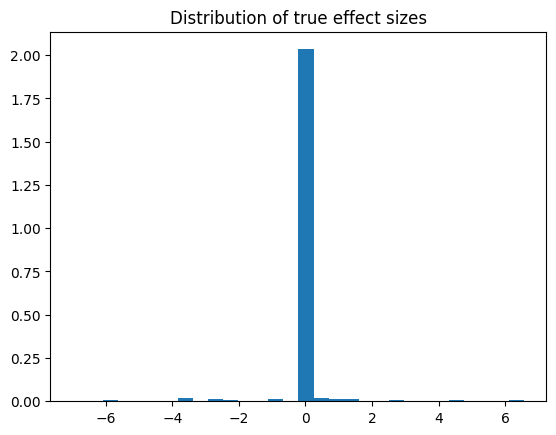

42/500 true non-zero effects


MFVI:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping
VI training time: 6.602 s


Gibbs: 100%|██████████| 1500/1500 [01:54<00:00, 13.12it/s]


Gibbs training time: 114.312 s


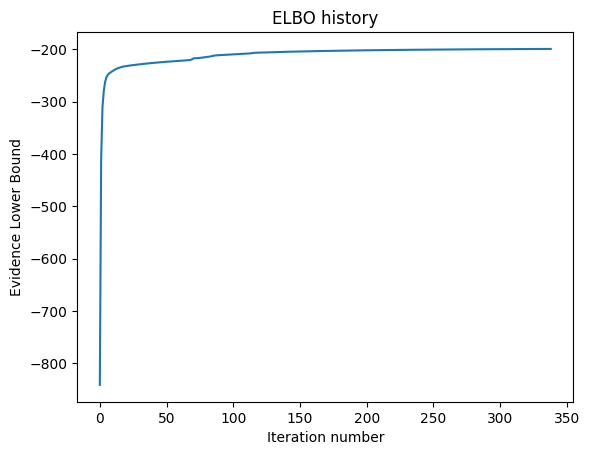

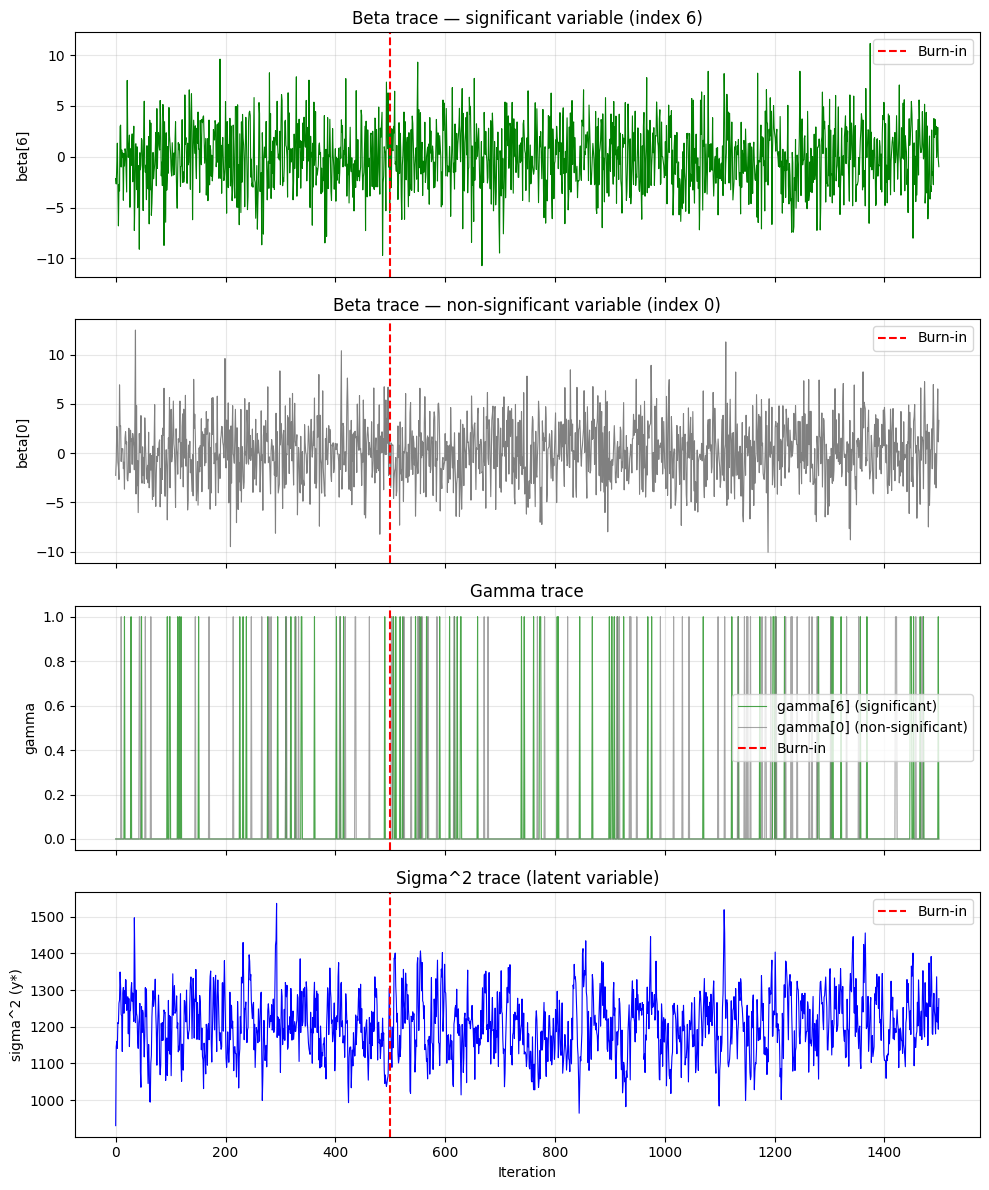

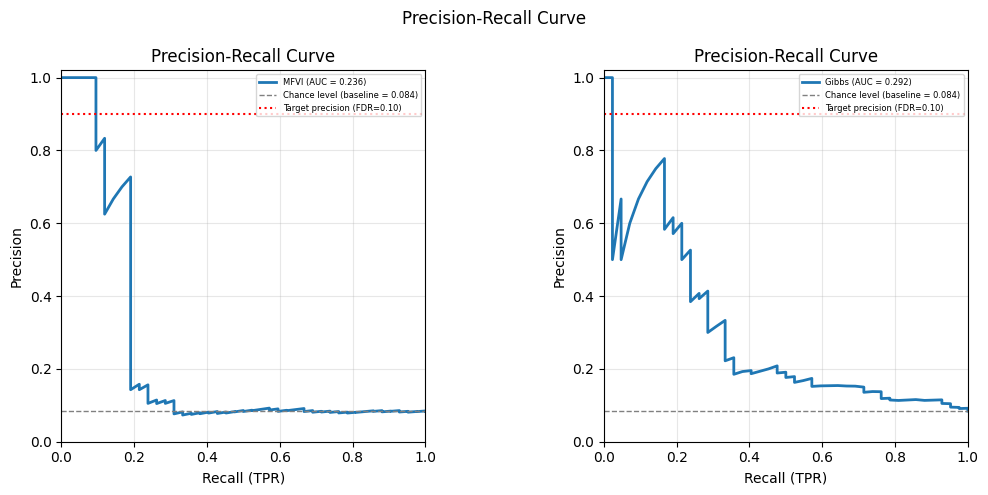

Stats per column - VI
------------
                         Predicted: significant  Predicted: non-significant
Actual: significant                           6                          36
Actual: non-significant                       3                         455
------------
        Metric  Value
0    Precision  0.667
1       Recall  0.143
2  Specificity  0.993
3          NPV  0.927
4          FDR  0.333
5          FPR  0.007
6          FNR  0.857
7     Accuracy  0.922
8     F1-score  0.235
9          MCC  0.284
Stats per column - VI
------------
                         Predicted: significant  Predicted: non-significant
Actual: significant                           1                          41
Actual: non-significant                       0                         458
------------
        Metric  Value
0    Precision  1.000
1       Recall  0.024
2  Specificity  1.000
3          NPV  0.918
4          FDR  0.000
5          FPR  0.000
6          FNR  0.976
7     Accuracy  0.918
8     F1

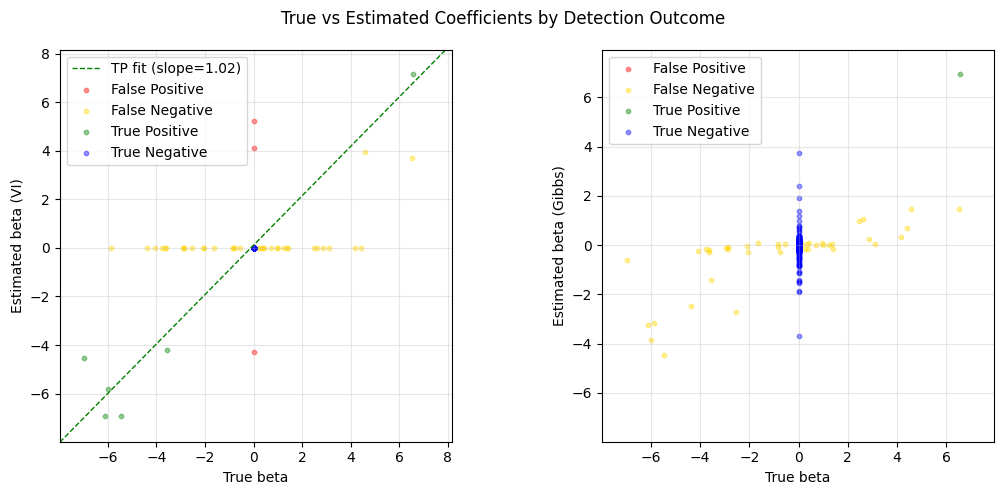

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload

import simulate_data as sim
reload(sim)

import mfvb
reload(mfvb)
from mfvb import q_tobit

import evaluation as ev
reload(ev)

import gibbs 
reload(gibbs)
from gibbs import gibbs_disc_spike_slab

#------------------- initialize results dict --------------------#
def flatten_config(config: dict, keep_as_str: tuple = ("params",)) -> dict:
    """Flatten a nested dict into a single-level dict.
    Keys unique across the whole config keep their original name.
    Keys that appear in more than one place get prefixed with their parent group name.
    Keys listed in `keep_as_str` are NOT flattened further — they are kept as a string.
    """

    def collect_all_keys(d: dict, keys: list):
        for key, value in d.items():
            if key in keep_as_str:
                keys.append(key)
            elif isinstance(value, dict):
                collect_all_keys(value, keys)
            else:
                keys.append(key)

    # 1st pass: find which keys appear more than once anywhere in the config
    all_keys = []
    collect_all_keys(config, all_keys)
    duplicate_keys = {k for k in all_keys if all_keys.count(k) > 1}

    # 2nd pass: build the flattened dict, prefixing only duplicate keys
    def _flatten(d: dict, parent_key: str = "") -> dict:
        items = {}
        for key, value in d.items():
            if key in keep_as_str and isinstance(value, dict):
                new_key = f"{parent_key}_{key}" if (key in duplicate_keys and parent_key) else key
                items[new_key] = str(value)
            elif isinstance(value, dict):
                items.update(_flatten(value, parent_key=key))
            else:
                new_key = f"{parent_key}_{key}" if (key in duplicate_keys and parent_key) else key
                items[new_key] = value
        return items

    return _flatten(config)

results = flatten_config(config)
results["pip_tr"] = PIP_TR
results["seed"] = SEED
results["time"] = timestamp
results["tau2_init"] = tau2
results["pi0_init"] = pi0

def reorder_dict(d: dict, first_keys: list) -> dict:
    reordered = {k: d[k] for k in first_keys if k in d}
    reordered.update({k: v for k, v in d.items() if k not in first_keys})
    return reordered


results = reorder_dict(results, ["time", "seed"])

# ------------------ simulate data ------------------------------ #


rng = np.random.default_rng(SEED)

n,d, method, params, intercept = config["X_design"].values()
r2, perc_sig, l_perc, u_perc = config["experiment"].values()

snr = r2/(1-r2)
beta_scale = 10

if method == "corr_block":
    X = sim.X_corr_blocks(n, d, **params, seed = SEED, intercept = intercept)
else: 
    print("Unknown X_design simulation method")

    
#beta_true = sim.beta_sparse(d, beta_scale, perc_sig, seed = SEED)
#y, l, u, sigma_y_true, snr= sim.y_tobit_2(X, l_perc, u_perc, beta_true, snr = snr, seed=SEED)

input_folder = "simulations/X_design/scenario_1"

X = np.load(f"{input_folder}/X.npy")
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u, sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
beta_true = np.load(f"{input_folder}/beta.npy")
y = np.clip(ystar, l, u).copy()
tau2 = 10
pi0 = 0.1
method = None


mask_l   = (y == l)
mask_u   = (y == u)
mask_mid = ~mask_l & ~mask_u

print(f"Censored low: {mask_l.sum()}  |  uncensored: {mask_mid.sum()}  |  Censored high: {mask_u.sum()}")

plt.hist(beta_true, bins =30, density = True)
plt.title("Distribution of true effect sizes")
plt.show()

true_eff_ct = (beta_true != 0).sum()
print(f"{true_eff_ct}/{d} true non-zero effects")
results["true_effects_count"] = true_eff_ct 

# --------------------- inference ----------------------------#
import time

### VI ###

n_iter, em_warmup = config["vi_params"].values()

start = time.time()

model_vi = q_tobit(
    X, y,
    tau2=tau2,
    pi0=pi0, 
    seed=SEED,
)
model_vi.fit(n_iter=n_iter, em_warmup = em_warmup, gamma_seq=False)

end = time.time()

print(f"VI training time: {end - start:.3f} s")
results["VI_time"] = round(end - start, 4)

### Gibbs ##

n_iter, burn_in, em_warmup = config["gibbs_params"].values()

start = time.time()
model_gibbs = gibbs_disc_spike_slab(
    X, y,
    tau2=tau2,
    pi0=pi0,
    seed=SEED,
)

beta_samples, gamma_samples, sigma_samples = model_gibbs.fit(
    n_iter = n_iter, 
    em_warmup = 0,
    burn_in = burn_in, 
    gamma_seq = True,
    em =  False
)

end = time.time()

print(f"Gibbs training time: {end - start:.3f} s")
results["Gibbs_time"] = round(end - start, 4)


# --------------- diagnostics -------------------
pip_vi = model_vi.rho
pip_gibbs = np.mean(gamma_samples, axis=0)

sig_vi = model_vi.sig_vi(threshold=PIP_TR)
sig_gibbs = pip_gibbs > PIP_TR
sig_true = (beta_true != 0)

plt.plot(model_vi.elbo_history)
plt.title("ELBO history")
#plt.savefig(f"{folder}elbo_history.png")
plt.xlabel("Iteration number")
plt.ylabel("Evidence Lower Bound")
plt.show()

#path = f"{folder}gibbs_chains.png"
ev.viz_gibbs(sig_true, burn_in, model_gibbs, 
             #path = path
            )

# -------------- Precision-recall curve -------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
precision, recall, pr_auc = ev.plot_precision_recall_curve(sig_true, pip_vi, label="MFVI", target_fdr=0.1, ax = axes[0])
precision, recall, pr_auc = ev.plot_precision_recall_curve(sig_true, pip_gibbs, label="Gibbs", target_fdr=0.1, ax = axes[1])

fig.suptitle(f"Precision-Recall Curve")
plt.tight_layout()
#plt.savefig(f"{folder}precision_recall.png")
plt.show()


# ------------ confusion matrix and basic stats --------------------

TP, TN, FP, FN = ev.confusion_stats(sig_true, sig_vi)
confusion, stats = ev.compute_stats(TP, TN, FP, FN)
results["TP_vi"] = TP
results["TN_vi"] = TN
results["FP_vi"] = FP
results["FN_vi"] = FN

if method == "corr_block":
    k = params["k"]
    block_ids = np.repeat(np.arange(d // k), k)

    n_misattributed_blocks, n_misattributed_vars, pct_blocks, pct_cols = ev.count_misattributed_errors(
        sig_true, sig_vi, block_ids
    )
    results["misatr_vars_count_vi"] = n_misattributed_vars

print("Stats per column - VI")
print("------------")
print(confusion)
print("------------")
print(stats)

stats = stats.set_index("Metric")["Value"].to_dict()
results["precision_vi"] = stats["Precision"]
results["recall_vi"] = stats["Recall"]
results["MCC_vi"] = stats["MCC"]


TP, TN, FP, FN = ev.confusion_stats(sig_true, sig_gibbs)
confusion, stats = ev.compute_stats(TP, TN, FP, FN)
results["TP_gibbs"] = TP
results["TN_gibbs"] = TN
results["FP_gibbs"] = FP
results["FN_gibbs"] = FN

if method == "corr_block":
    n_misattributed_blocks, n_misattributed_vars, pct_blocks, pct_cols = ev.count_misattributed_errors(
        sig_true, sig_gibbs, block_ids
    )
    results["misatr_vars_count_gibbs"] = n_misattributed_vars

print("Stats per column - VI")
print("------------")
print(confusion)
print("------------")
print(stats)

stats = stats.set_index("Metric")["Value"].to_dict()
results["precision_gibbs"] = stats["Precision"]
results["recall_gibbs"] = stats["Recall"]
results["MCC_gibbs"] = stats["MCC"]


# --------- comparision of beta estimates -----------------

beta_vi = model_vi.m
beta_gibbs = np.mean(beta_samples, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ev.compare_effect_sizes(beta_true, beta_vi, sig_true, sig_vi, label = "VI", ax = axes[0])
ev.compare_effect_sizes(beta_true, beta_gibbs, sig_true, sig_gibbs, label = "Gibbs", ax = axes[1])
fig.suptitle(f"True vs Estimated Coefficients by Detection Outcome")
plt.tight_layout()
#plt.savefig(f"{folder}beta_estimates.png")
plt.show()


# ------------- results save -------------------
def append_dict_to_csv(data: dict, path: str):
    df_new = pd.DataFrame([data])

    if Path(path).exists():
        df_existing = pd.read_csv(path)
        common_cols = [c for c in df_new.columns if c in df_existing.columns]

        if not df_existing.empty and common_cols:
            merged = df_existing[common_cols].astype(str).merge(
                df_new[common_cols].astype(str), how="inner"
            )
            if not merged.empty:
                print("Duplicate row detected — skipping save.")
                return

        df_new = pd.concat([df_existing, df_new], ignore_index=True, sort=False)

    df_new.to_csv(path, header=True, index=False)


#path = f"{FOLDER}/results.csv"
#append_dict_to_csv(results, path)